In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [ ]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total bill($)'),
 Text(0, 0.5, 'Tip Amount($)')]

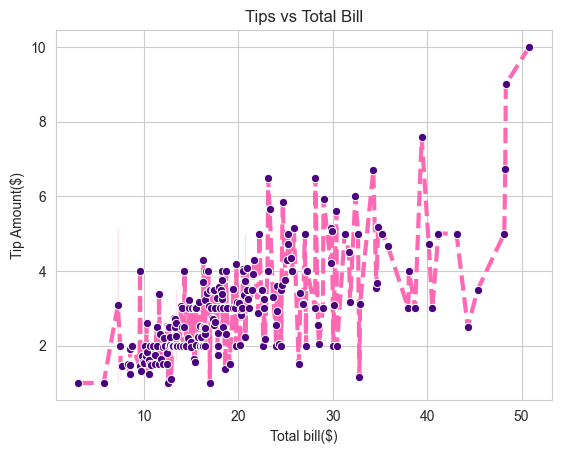

In [15]:
sns.set_style("whitegrid") #before draw the line plot, set the style
tipgraph = sns.lineplot(data=tips, x="total_bill", y="tip",
                        color="hotpink",
                        linestyle="--",
                        linewidth=3,
                        marker="o",
                        markerfacecolor="indigo")
tipgraph.set(title="Tips vs Total Bill", xlabel="Total bill($)", ylabel="Tip Amount($)")

[Text(0.5, 1.0, 'Tips vs. Total bill'),
 Text(0.5, 0, 'Total Bill($)'),
 Text(0, 0.5, 'Tips Amount($)')]

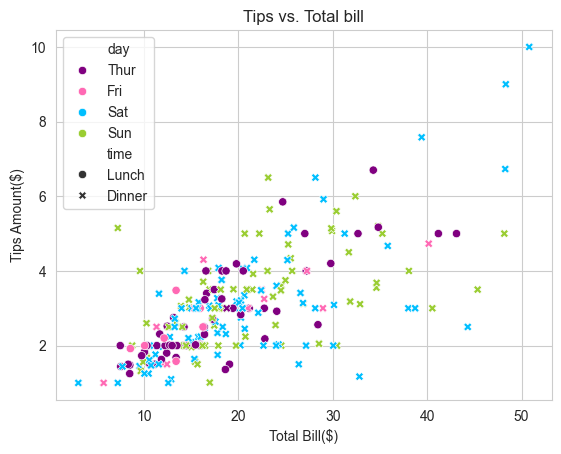

In [14]:
tipgraph = sns.scatterplot(data=tips, x="total_bill", y="tip",
                           style="time", hue="day",palette=["purple","hotpink","deepskyblue","yellowgreen"])
tipgraph.set(title="Tips vs. Total bill", xlabel="Total Bill($)", ylabel="Tips Amount($)")
# we use Seaborn because it is very easy to represent multilple variables with different visual elements (seperate day and time automatically without any defination by us)

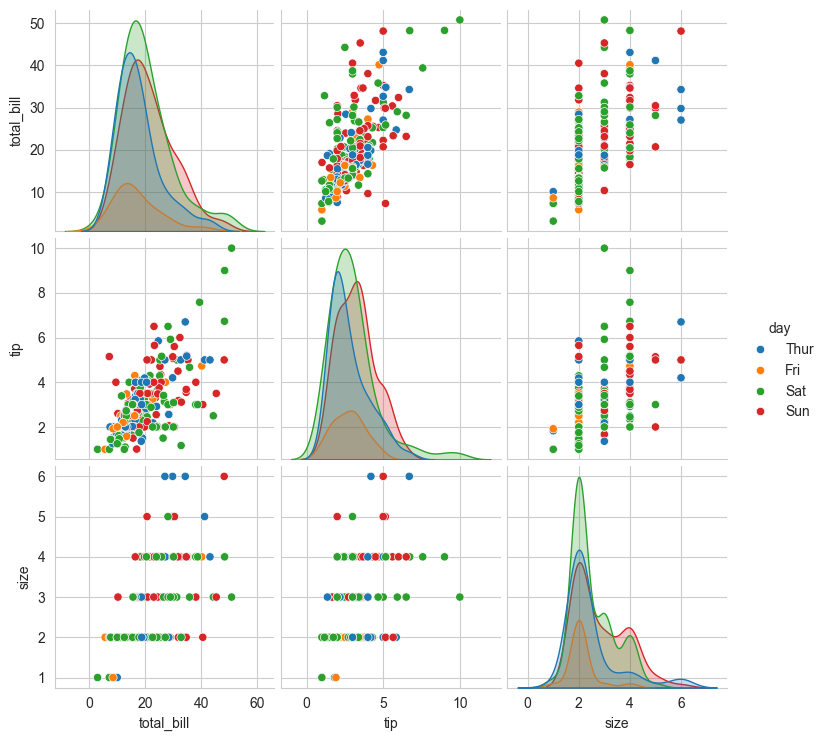

In [ ]:
#pairplot
sns.pairplot(data=tips, hue="day") #categorical variables are not included here
#if we add hue=day here, means coloring data points by different days

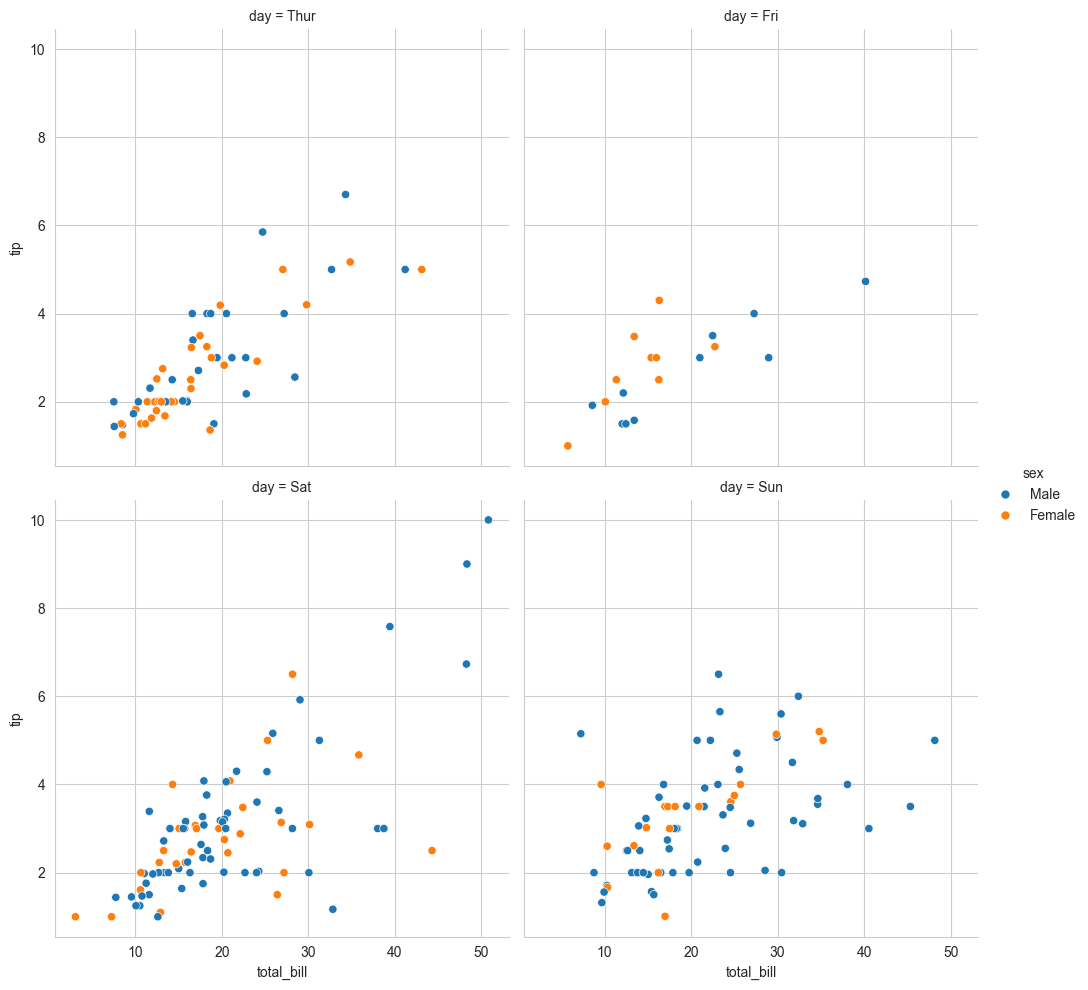

In [ ]:
#relplot
daysplot = sns.relplot(data=tips, x="total_bill", y="tip",
                       hue="sex", col="day", #color diff by sex; column them by diff days
                       kind="scatter", col_wrap=2) #draw a scatterplot; wrap the columns in 2 

In [19]:
#plotly
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [ ]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
graph = go.Figure()
graph.add_trace(go.Bar(x=x1,y=y1))
graph.update_layout(title="Pirate Scores",
                    xaxis_title="Pirates",
                    yaxis_title="Score")
# save them in local folder as html
# graph.write_html("pirategraph.html")

In [27]:
graph=go.Figure()
graph.add_trace(go.Scatter(x=x1,y=y1,mode="markers", 
                           marker=dict(
                               size=15, color="hotpink",opacity=1,
                               line=dict(width=5, color="purple")
                           ))) 
graph.update_layout(title="Interactive Pirate Plot",
                    xaxis_title="Pirates",
                    yaxis_title="Scores",
                    width=500, height=500)
#mode='markers' points only
#'lines' = lines only
#'lines+markers' = both


In [29]:
#wordclouds
df = pd.read_csv("movie_quotes.csv")
print(df)

                                                 quote  \
0                      Do, or do not. There is no try.   
1    Listen to them. Children of the night. What mu...   
2                              It's alive! It's alive!   
3    Oh, no, it wasn't the airplanes. It was Beauty...   
4    Magic Mirror on the wall, who is the fairest o...   
..                                                 ...   
727  I didn't know if you were lost. Stick with me....   
728  This guy's awesome! He's holding his own while...   
729     Murder is murder, it don’t matter who you are.   
730  You know what a lion is? A lion is a strong an...   
731  That was the best acting i've ever seen in my ...   

                                              movie   type  year  
0    Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                           Dracula  movie  1931  
2                                      Frankenstein  movie  1931  
3                                  

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

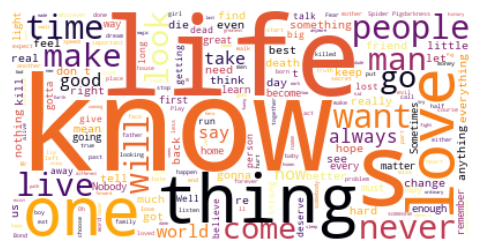

In [34]:
#generate the wordcloud
text="".join(each for each in df.quote)
wordcloud = WordCloud(background_color="white", colormap="inferno").generate(text)
# use matplotlib syntax to put our image in a figure
fig, ax=plt.subplots(figsize=(7,3))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off") #remove the axis

/Users/springzhou/DSI/visualization/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



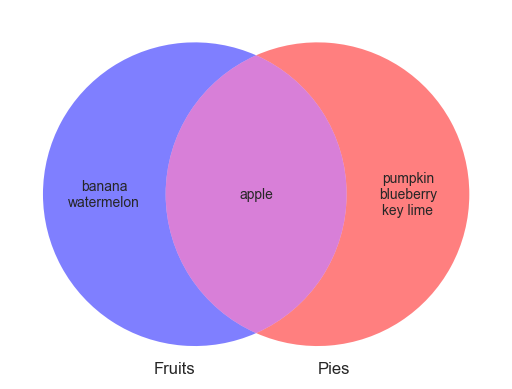

In [37]:
#venn diagram
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])
diagram=venn2_unweighted([A,B],
                         set_labels=("Fruits", "Pies"),
                         set_colors=("blue", "red"),
                         alpha=0.5)
#there is a documentation for the specific number of diff regions
diagram.get_label_by_id("10").set_text("\n".join(A-B))
diagram.get_label_by_id("11").set_text("\n".join(A&B))
diagram.get_label_by_id("01").set_text("\n".join(B-A))